# Economy, Energy Mix, and Responsibility in Global CO2 Emissions

Starter notebook for the CS 328 writing assignment.

**Main question:** How do economic scale, energy mix, and policy-linked structural choices shape national CO2 emissions?

**Team split:**

- Person 1: Economy
- Person 2: Energy mix
- Person 3: Policy, trade, and structural change

Use this as a shared template. Each person can work independently in their section, then combine the final graphs and 250-300 word writeups into one notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('../data/raw/owid-co2-data.csv')
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

df = pd.read_csv(DATA)
countries = df[df['iso_code'].notna() & (df['iso_code'].str.len() == 3)].copy()

print('Rows, columns:', df.shape)
print('Years:', df['year'].min(), 'to', df['year'].max())
print('Countries/territories with ISO codes:', countries['country'].nunique())
countries.head()

Rows, columns: (50411, 79)
Years: 1750 to 2024
Countries/territories with ISO codes: 218


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Shared Data Coverage

Different indicators have different latest usable years. Use:

- 2022 for GDP-heavy analysis.
- 2023 for consumption/trade analysis.
- 2024 for latest fuel-mix analysis.

In [2]:
coverage_specs = {
    'GDP + population + CO2': ['gdp', 'population', 'co2', 'co2_per_capita'],
    'Trade/consumption CO2': ['consumption_co2', 'trade_co2_share', 'co2'],
    'Energy intensity': ['energy_per_capita', 'co2_per_unit_energy'],
    'Fuel mix': ['coal_co2', 'oil_co2', 'gas_co2', 'co2'],
}

rows = []
for label, cols in coverage_specs.items():
    valid = countries.dropna(subset=cols)
    counts = valid.groupby('year').size()
    latest = counts[counts >= 80].index.max()
    rows.append({
        'section': label,
        'latest_year_with_80plus_countries': latest,
        'country_count': int(counts.loc[latest]),
    })

pd.DataFrame(rows)

,section,latest_year_with_80plus_countries,country_count
0,GDP + population + CO2,2022,164
1,Trade/consumption CO2,2023,120
2,Energy intensity,2023,203
3,Fuel mix,2024,110


In [3]:
def spearman_corr(x, y):
    return pd.Series(x).rank().corr(pd.Series(y).rank())


def permutation_corr_test(x, y, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.array(x, copy=True)
    y = np.array(y, copy=True)
    observed = spearman_corr(x, y)
    count = 0
    for _ in range(n):
        if abs(spearman_corr(x, rng.permutation(y))) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)


def permutation_mean_test(a, b, n=5000, seed=1):
    rng = np.random.default_rng(seed)
    a = np.array(a, copy=True)
    b = np.array(b, copy=True)
    observed = a.mean() - b.mean()
    pool = np.concatenate([a, b])
    n_a = len(a)
    count = 0
    for _ in range(n):
        permuted = rng.permutation(pool)
        diff = permuted[:n_a].mean() - permuted[n_a:].mean()
        if abs(diff) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)

## Person 1: Economy

**H1A:** Higher GDP per capita is associated with higher CO2 per capita.

**H1B:** GDP per capita alone does not reliably predict CO2 per GDP; energy mix and economic structure explain variation better.

Write 250-300 words after making 2-3 graphs.

In [4]:
h1 = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'co2_per_capita', 'co2_per_gdp']
).copy()
h1 = h1[h1['population'] >= 1_000_000]
h1['gdp_per_capita'] = h1['gdp'] / h1['population']

stats_rows = []
for x, y, label in [
    ('gdp_per_capita', 'co2_per_capita', 'GDP per capita vs CO2 per capita'),
    ('gdp_per_capita', 'co2_per_gdp', 'GDP per capita vs CO2 per GDP'),
]:
    d = h1[[x, y]].dropna()
    r, p = permutation_corr_test(d[x], d[y], n=1000)
    stats_rows.append({'comparison': label, 'spearman_r': round(r, 3), 'permutation_p': round(p, 4), 'n': len(d)})

pd.DataFrame(stats_rows)

,comparison,spearman_r,permutation_p,n
0,GDP per capita vs CO2 per capita,0.891,0.0010,153
1,GDP per capita vs CO2 per GDP,0.083,0.3007,153


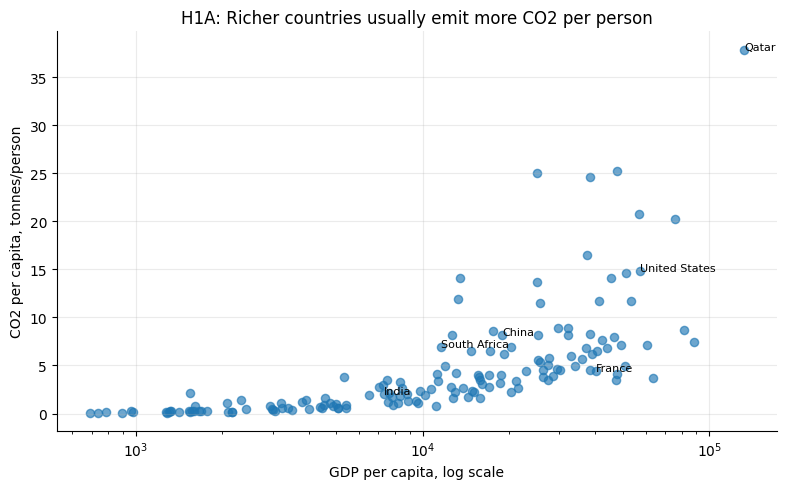

In [5]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_capita'], alpha=0.65, s=35)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H1A: Richer countries usually emit more CO2 per person')

for name in ['United States', 'China', 'India', 'Qatar', 'France', 'South Africa']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1a_gdp_vs_co2_per_capita.png', dpi=180)
plt.show()

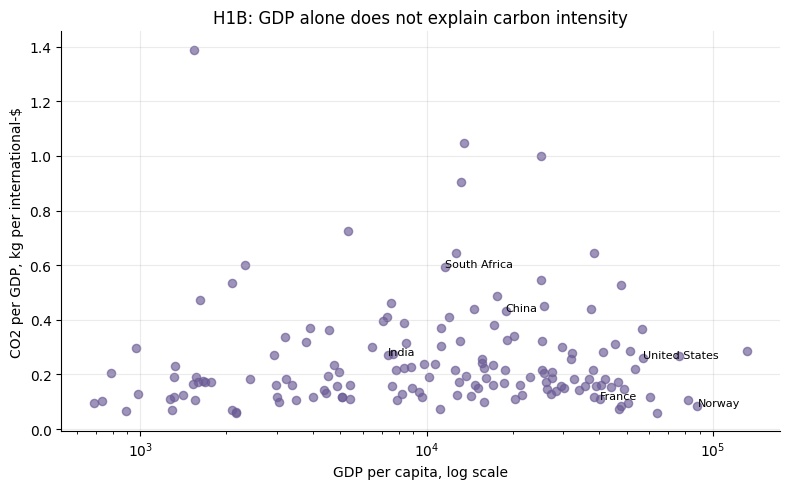

In [6]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_gdp'], alpha=0.65, s=35, color='#6b5b95')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per GDP, kg per international-$')
ax.set_title('H1B: GDP alone does not explain carbon intensity')

for name in ['China', 'India', 'South Africa', 'United States', 'France', 'Norway']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_gdp'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1b_gdp_vs_co2_per_gdp.png', dpi=180)
plt.show()

### Person 1 Writeup: Economy

The economy section shows that wealth is strongly associated with emissions per person, but it is not a complete explanation of emissions intensity. Using 2022, the latest year with broad GDP coverage, countries with population above one million show a strong positive relationship between GDP per capita and CO2 per capita: the Spearman correlation is about 0.891. This supports H1A. Richer countries usually have larger homes, more transport, more electricity demand, and more energy-intensive consumption, so their average resident tends to be responsible for more CO2.

H1B is more interesting because the relationship nearly disappears when emissions are divided by GDP. GDP per capita and CO2 per GDP have a weak Spearman correlation of only about 0.083. This means rich countries are not automatically more carbon-intensive per dollar of output. Some relatively wealthy countries have lower CO2 per GDP because their economies are more service-oriented or their electricity systems are cleaner, while some middle-income or fossil-fuel-dependent countries produce much more CO2 for each unit of economic output. The outliers matter: countries such as Turkmenistan, Trinidad and Tobago, Mongolia, Bahrain, and North Korea rank high on CO2 per GDP for very different reasons.

The conclusion is that economic development increases per-person emissions, but GDP alone does not determine how dirty an economy is. Per-capita emissions measure individual footprint; CO2 per GDP measures production efficiency. Both are needed for a fair comparison.

## Person 2: Energy Mix

**H2A:** Coal-heavy countries have higher CO2 emissions intensity.

**H2B:** Energy use per capita strongly predicts CO2 per capita, but cleaner energy mixes create exceptions.

Write 250-300 words after making 2-3 graphs.

In [7]:
h2 = countries[countries['year'] == 2024].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2', 'co2', 'co2_per_unit_energy', 'population']
).copy()
h2 = h2[(h2['population'] >= 1_000_000) & (h2['co2'] > 20)]
h2['known_fossil_co2'] = h2[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
h2 = h2[h2['known_fossil_co2'] > 0]
h2['coal_share'] = h2['coal_co2'] / h2['known_fossil_co2']

high_coal = h2[h2['coal_share'] >= 0.5]['co2_per_unit_energy'].dropna()
low_coal = h2[h2['coal_share'] < 0.2]['co2_per_unit_energy'].dropna()
diff, p = permutation_mean_test(high_coal, low_coal, n=2000)

pd.DataFrame([
    {'group': 'coal share >= 50%', 'n': len(high_coal), 'mean_co2_per_unit_energy': high_coal.mean()},
    {'group': 'coal share < 20%', 'n': len(low_coal), 'mean_co2_per_unit_energy': low_coal.mean()},
    {'group': 'difference and p-value', 'n': '', 'mean_co2_per_unit_energy': f'diff={diff:.3f}, p={p:.4f}'},
])

,group,n,mean_co2_per_unit_energy
0,coal share >= 50%,8,0.273625
1,coal share < 20%,39,0.167513
2,difference and p-value,,"diff=0.106, p=0.0005"


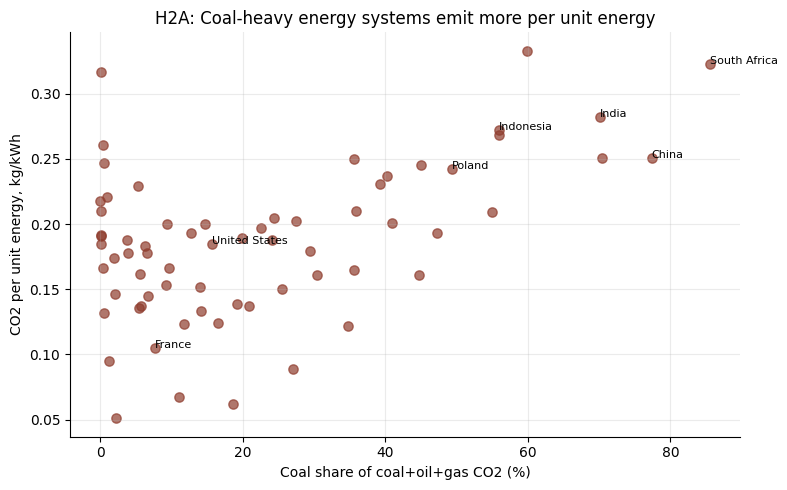

In [8]:
fig, ax = plt.subplots()
ax.scatter(h2['coal_share'] * 100, h2['co2_per_unit_energy'], alpha=0.7, s=45, color='#8f3d2e')
ax.set_xlabel('Coal share of coal+oil+gas CO2 (%)')
ax.set_ylabel('CO2 per unit energy, kg/kWh')
ax.set_title('H2A: Coal-heavy energy systems emit more per unit energy')

for name in ['South Africa', 'China', 'India', 'Indonesia', 'Poland', 'United States', 'France']:
    row = h2[h2['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['coal_share'].iloc[0] * 100, row['co2_per_unit_energy'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2a_coal_share_vs_energy_intensity.png', dpi=180)
plt.show()

Spearman r = 0.970, permutation p = 0.0010, n = 159


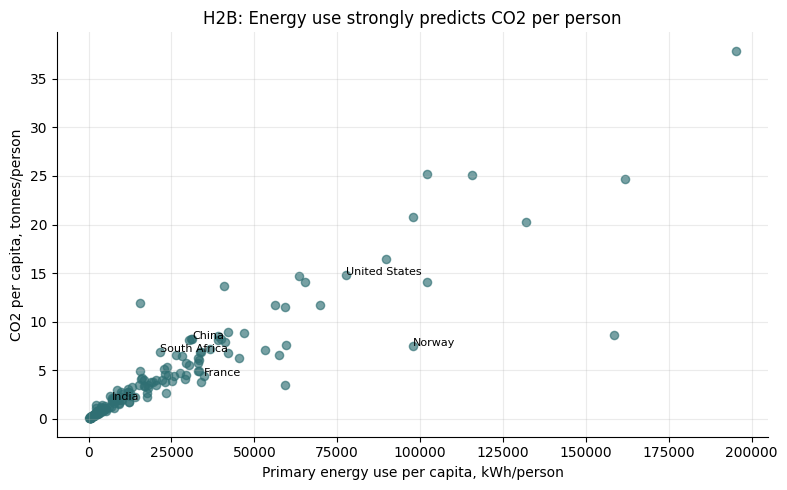

In [9]:
h2b = countries[countries['year'] == 2022].dropna(
    subset=['energy_per_capita', 'co2_per_capita', 'population']
).copy()
h2b = h2b[h2b['population'] >= 1_000_000]

r, p = permutation_corr_test(h2b['energy_per_capita'], h2b['co2_per_capita'], n=1000)
print(f'Spearman r = {r:.3f}, permutation p = {p:.4f}, n = {len(h2b)}')

fig, ax = plt.subplots()
ax.scatter(h2b['energy_per_capita'], h2b['co2_per_capita'], alpha=0.65, s=35, color='#2f6f73')
ax.set_xlabel('Primary energy use per capita, kWh/person')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H2B: Energy use strongly predicts CO2 per person')

for name in ['United States', 'China', 'India', 'Norway', 'France', 'South Africa']:
    row = h2b[h2b['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['energy_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2b_energy_vs_co2_per_capita.png', dpi=180)
plt.show()

### Person 2 Writeup: Energy Mix

The energy-mix section explains why countries with similar levels of development can have very different emissions profiles. H2A is supported by the 2024 fuel data. Among countries with population above one million and more than 20 million tonnes of annual CO2, countries where coal makes up at least half of coal+oil+gas emissions average about 0.274 kg CO2 per kWh of primary energy. Countries where coal contributes less than 20% average about 0.168 kg CO2 per kWh. The gap is large: about 0.106 kg CO2 per kWh. This is visible in the coal-share scatterplot, where South Africa, China, India, Vietnam, Kazakhstan, Indonesia, and the Philippines sit high on coal dependence and energy carbon intensity.

H2B is also strongly supported. In 2022, energy use per capita and CO2 per capita have a Spearman correlation of about 0.970. That means the simplest predictor of a country's per-person CO2 emissions is how much energy each person uses. However, the plot also shows why energy quantity is not the whole story. Countries with high energy use can have lower emissions if their electricity and industry rely more on nuclear, hydro, renewables, or lower-carbon fuels. France and Norway are useful examples to compare with coal-heavy economies.

The main lesson is that climate outcomes depend on both demand and supply. A country can reduce emissions by lowering energy waste, but the bigger structural issue is often the fuel mix behind each unit of energy.

## Person 3: Policy, Trade, and Structural Change

**H3A:** Production-based and consumption-based emissions change which countries look responsible.

**H3B:** Some countries show declining emissions over time, possibly due to policy, technology, or structural economic change.

Be careful: this dataset can show decline, but it cannot prove the exact cause without extra policy data.

In [10]:
h3 = countries[countries['year'] == 2023].dropna(
    subset=['co2', 'consumption_co2', 'trade_co2_share', 'population']
).copy()
h3 = h3[(h3['population'] >= 1_000_000) & (h3['co2'] > 5)]

h3[['country', 'co2', 'consumption_co2', 'trade_co2_share']].sort_values(
    'trade_co2_share', ascending=False
).head(10)

,country,co2,consumption_co2,trade_co2_share
21118,Hong Kong,32.957,144.164,337.429
44294,Switzerland,31.977,118.330,270.040
41363,Singapore,51.068,186.926,266.036
31960,Nepal,18.348,47.279,157.683
43582,Sri Lanka,19.166,46.439,142.300
5438,Belgium,84.703,196.605,132.110
25603,Latvia,6.590,13.362,102.763
7036,Botswana,7.249,14.509,100.160
8461,Cambodia,21.412,39.064,82.444
10981,Costa Rica,8.473,14.692,73.405


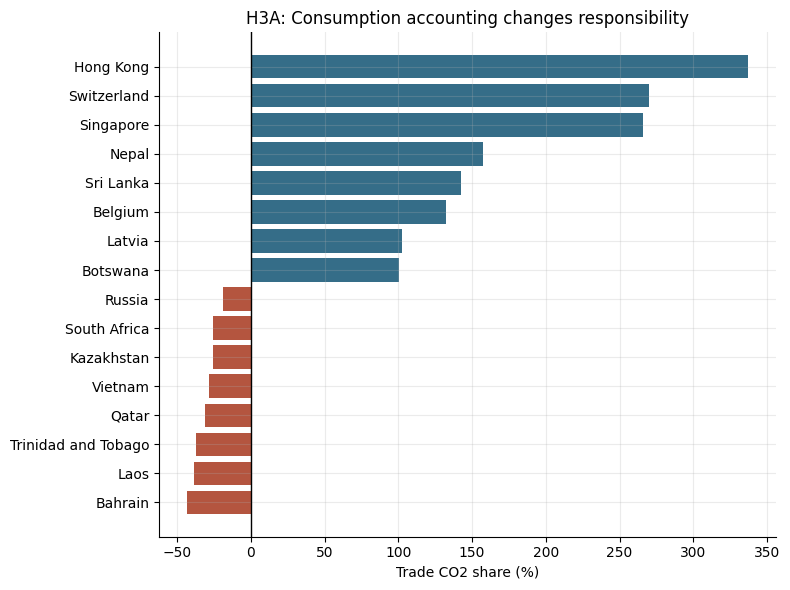

In [11]:
importers = h3.sort_values('trade_co2_share', ascending=False).head(8)
exporters = h3.sort_values('trade_co2_share', ascending=True).head(8)
trade_plot = pd.concat([exporters, importers]).sort_values('trade_co2_share')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#b4553f' if v < 0 else '#356d88' for v in trade_plot['trade_co2_share']]
ax.barh(trade_plot['country'], trade_plot['trade_co2_share'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Trade CO2 share (%)')
ax.set_title('H3A: Consumption accounting changes responsibility')
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_trade_co2_share.png', dpi=180)
plt.show()

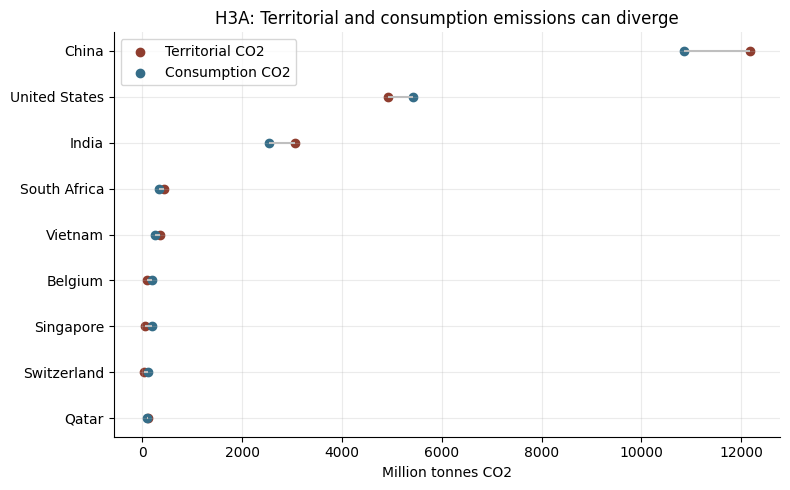

In [12]:
selected = ['Switzerland', 'Singapore', 'Belgium', 'United States', 'China', 'India', 'Vietnam', 'South Africa', 'Qatar']
pairs = h3[h3['country'].isin(selected)].sort_values('consumption_co2')

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(pairs))
ax.hlines(y, pairs['co2'], pairs['consumption_co2'], color='0.75')
ax.scatter(pairs['co2'], y, label='Territorial CO2', color='#8f3d2e')
ax.scatter(pairs['consumption_co2'], y, label='Consumption CO2', color='#356d88')
ax.set_yticks(y)
ax.set_yticklabels(pairs['country'])
ax.set_xlabel('Million tonnes CO2')
ax.set_title('H3A: Territorial and consumption emissions can diverge')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_territorial_vs_consumption.png', dpi=180)
plt.show()

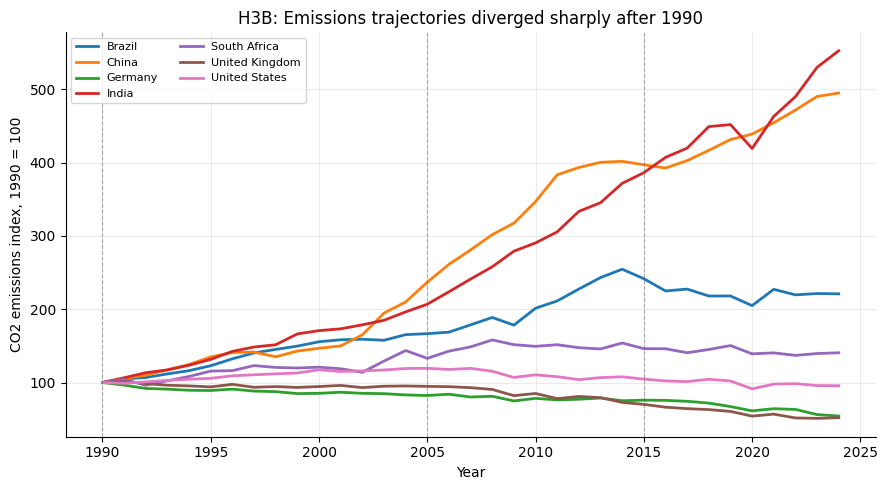

In [13]:
trend_countries = ['United States', 'China', 'India', 'Germany', 'United Kingdom', 'Brazil', 'South Africa']
base_year = 1990
trend = countries[countries['country'].isin(trend_countries) & (countries['year'] >= base_year)].copy()
trend = trend.dropna(subset=['co2'])
base = trend[trend['year'] == base_year][['country', 'co2']].rename(columns={'co2': 'base_co2'})
trend = trend.merge(base, on='country', how='inner')
trend['co2_index_1990_100'] = 100 * trend['co2'] / trend['base_co2']

fig, ax = plt.subplots(figsize=(9, 5))
for country, g in trend.groupby('country'):
    ax.plot(g['year'], g['co2_index_1990_100'], label=country, linewidth=2)
for year in [1990, 2005, 2015]:
    ax.axvline(year, color='0.4', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('CO2 emissions index, 1990 = 100')
ax.set_xlabel('Year')
ax.set_title('H3B: Emissions trajectories diverged sharply after 1990')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'h3b_trend_co2_index_1990.png', dpi=180)
plt.show()

### Person 3 Writeup: Policy, Trade, and Structural Change

The policy and trade section shows that responsibility changes when emissions are counted by consumption instead of production. H3A is supported by the 2023 consumption-based data. Countries such as Switzerland, Singapore, Hong Kong, and Belgium have consumption emissions far above their territorial emissions, meaning a large part of their carbon footprint is embedded in imported goods and services. Switzerland's trade-adjusted share is about +270%, Singapore's is about +266%, and Belgium's is about +132%. In contrast, Bahrain, Qatar, Vietnam, Kazakhstan, South Africa, Russia, and India have negative trade adjustments, meaning they produce more emissions domestically than their residents consume directly.

This matters because territorial accounting can make importer economies look cleaner than they are, while making exporter or manufacturing economies look dirtier. A fair climate discussion should therefore include both numbers: production emissions show where CO2 physically enters the atmosphere, while consumption emissions show who ultimately benefits from the goods being produced.

H3B is supported more cautiously. The indexed trend graph shows that some countries have reduced annual CO2 emissions since 1990, while others have grown sharply. By 2024, the United Kingdom and Germany are near 52% and 54% of their 1990 emissions, respectively. The United States is slightly below its 1990 level, while China and India are roughly five times higher. These declines are consistent with policy, technology shifts, deindustrialization, and cleaner energy, but this dataset alone cannot prove the exact cause. The correct claim is structural change, not simple policy causality.

## Optional Bonus: Land-Use Change

Only add this if the final notebook has room. It is a strong natural-resources angle, but the main three-person split already works without it.

In [14]:
h_bonus = countries[countries['year'] == 2024].dropna(
    subset=['co2', 'co2_including_luc', 'land_use_change_co2', 'population']
).copy()
h_bonus = h_bonus[(h_bonus['population'] >= 1_000_000) & (h_bonus['co2'] > 5)]
h_bonus['luc_to_fossil_pct'] = 100 * h_bonus['land_use_change_co2'] / h_bonus['co2']

h_bonus[['country', 'co2', 'land_use_change_co2', 'co2_including_luc', 'luc_to_fossil_pct']].sort_values(
    'luc_to_fossil_pct', ascending=False
).head(12)

,country,co2,land_use_change_co2,co2_including_luc,luc_to_fossil_pct
12406,Democratic Republic of Congo,5.904,648.196,654.101,10978.929539
11257,Cote d'Ivoire,14.829,237.571,252.400,1602.070268
14992,Ethiopia,17.837,214.036,231.873,1199.955149
5789,Benin,6.066,44.087,50.153,726.788658
50135,Zambia,12.043,62.589,74.632,519.712696
28708,Mali,6.979,31.321,38.300,448.789225
8012,Burkina Faso,6.508,28.445,34.953,437.077443
45099,Tanzania,20.018,79.022,99.040,394.754721
6513,Bolivia,28.709,110.939,139.648,386.425859
31261,Mozambique,8.613,30.572,39.184,354.951817


## Final Thesis Draft

National CO2 emissions are not explained by wealth alone. Economic development is associated with higher per-person emissions, but the final emissions outcome depends on how much energy people use, whether that energy comes from coal-heavy systems, whether emissions are counted where goods are produced or consumed, and whether countries have managed to bend their emissions trend downward over time.